# Basic Visualization
In this chapter, we will have a basic visualization of the data we just downloaded. 

Urban climate data (such as temperature, air quality, or cooling capacity) often contains many cities, years, and variables. Raw tables alone make it difficult to understand patterns or differences quickly. Visualization helps transform complex data into clear insights that are easier to interpret and communicate.

Why visualization matters

- Reveals trends over time (e.g., rising urban temperatures)
- Shows spatial patterns (e.g., hotter city centers vs. greener outskirts)
- Makes comparisons between cities or regions easier
- 
Helps detect outliers or unusual values

Tables vs. Plots

- Tables are best for checking exact numbers and verifying data
- Plots are best for identifying patterns, trends, and relationships
- Use tables for precision, plots for understanding

Common beginner mistakes

- Plotting too many variables in one chart
- Ignoring time scale (daily vs. yearly data)
- Missing axis labels or units
- Using misleading scales
- Overcrowding maps with too many labels

Clear, focused, and transparent visualizations are essential in urban climate analysis, especially when results inform planning and policy decisions.

# Visualizing urban climate data from a GeoPackage (.gpkg)
We assuem the GeoPackage contains:
- a geometry column
- a numeric climate variable
- optionally a time or city identifier

Simple plot

        AGS       GEN   NUTS     Shape_Leng    Shape_Area  \
0  09563000     Fürth  DE253   49209.551437  6.334375e+07   
1  09162000   München  DE212  118084.194383  3.108342e+08   
2  09461000   Bamberg  DE241   44492.667416  5.464215e+07   
3  09262000    Passau  DE222   61360.769487  6.956591e+07   
4  09564000  Nürnberg  DE254  153997.952475  1.866370e+08   

   Pop_Benefit_Percent                                           geometry  
0            49.550707  MULTIPOLYGON (((4392577.758 2936451.016, 43926...  
1            70.270877  MULTIPOLYGON (((4432133.707 2774479.63, 443212...  
2            77.048748  MULTIPOLYGON (((4388203.406 2978639.586, 43882...  
3            78.069768  MULTIPOLYGON (((4570163.06 2838978.815, 457018...  
4            46.746620  MULTIPOLYGON (((4401927.814 2917518.273, 44019...  
Index(['AGS', 'GEN', 'NUTS', 'Shape_Leng', 'Shape_Area', 'Pop_Benefit_Percent',
       'geometry'],
      dtype='object')


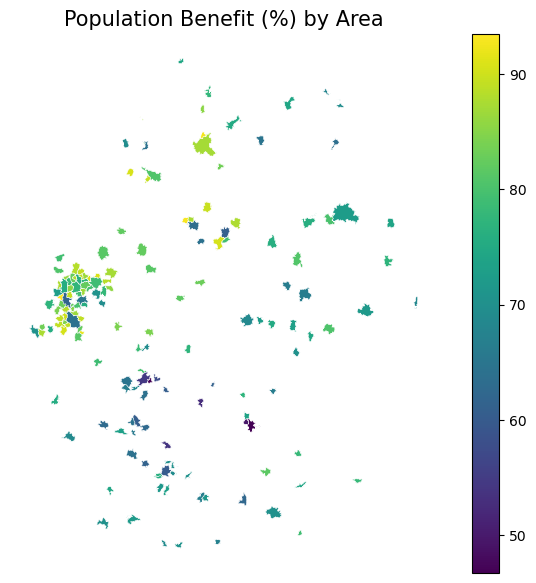

In [22]:

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

#1. load the GeoPackage file
gdf = gpd.read_file ("../../00_data/downloaded_data/climate_regulation_in_cities.gpkg" )

#2. inspect the data structure
print(gdf.head())
print(gdf.columns)

# 3) Pick a numeric column to visualize (here: Pop_Benefit_Percent)
value_col = "Pop_Benefit_Percent"

# Safety check (prevents KeyError)
if value_col not in gdf.columns:
    raise ValueError(
        f"Column '{value_col}' not found. Available columns: {list(gdf.columns)}"
    )

# 4) Ensure the chosen column is numeric (sometimes it loads as text)
gdf[value_col] = pd.to_numeric(gdf[value_col], errors="coerce")

# 5) Create a readable map plot
fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",          # readable, colorblind-friendly for many viewers
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    missing_kwds={"color": "lightgrey", "label": "Missing"}
)

# 6) Add a clear title (and optional subtitle-style info)
ax.set_title("Population Benefit (%) by Area", fontsize=15)
ax.set_axis_off()

plt.show()



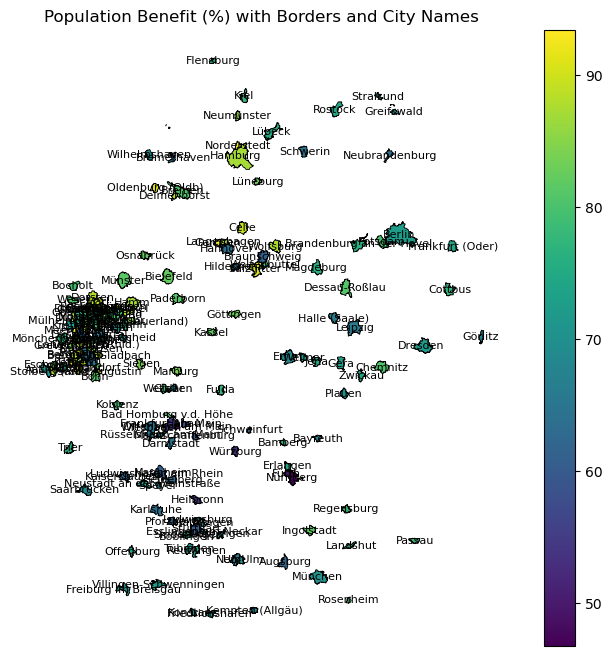

In [23]:
# add city names
fig, ax = plt.subplots(figsize=(10, 8))

gdf.plot(
    column="Pop_Benefit_Percent",
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none"
)

gdf.boundary.plot(ax=ax, linewidth=0.6, color="black")

# Add labels
label_points = gdf.geometry.representative_point()

for x, y, name in zip(label_points.x, label_points.y, gdf["GEN"]):
    ax.text(x, y, name, fontsize=8, ha="center", va="center")

ax.set_title("Population Benefit (%) with Borders and City Names")
ax.set_axis_off()

plt.show()


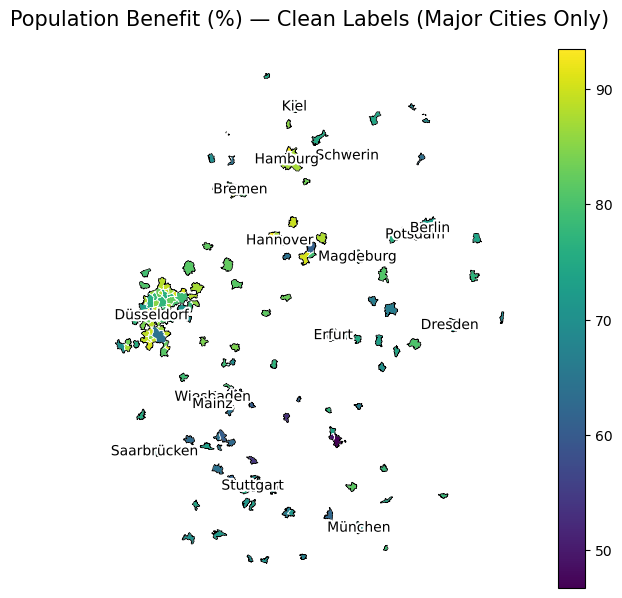

In [32]:
# --- Clean labels cell: label only a curated set of major cities ---
# Uses:
#  - only a small set of names (reduces clutter)
#  - label halo for readability
#  - representative_point() so labels fall inside polygons

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

# Pick which cities to label (edit this list to match your reference map)
major_cities = {
    "Hamburg", "Berlin", "München", "Munich", "Stuttgart", "Dresden",
    "Bremen", "Hannover", "Hanover", "Kiel", "Schwerin", "Potsdam",
    "Magdeburg", "Erfurt", "Wiesbaden", "Mainz", "Saarbrücken", "Saarbrucken",
    "Düsseldorf", "Duesseldorf"
}

name_col = "GEN"  # your city/district name column

# Filter to label only major cities AND only where affected
affected = gdf[gdf[value_col].fillna(0) > 0].copy()
label_gdf = affected[affected[name_col].astype(str).isin(major_cities)].copy()

# Borders
city_borders = gdf.boundary
country_outline = gdf.dissolve().boundary

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey"}
)

city_borders.plot(ax=ax, linewidth=0.4, color="white", alpha=0.9)
country_outline.plot(ax=ax, linewidth=0.5, color="black")

# Add clean labels (with white halo)
if len(label_gdf) > 0:
    pts = label_gdf.geometry.representative_point()
    for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
        txt = ax.text(
            x, y, name,
            fontsize=10, fontweight="regular",
            ha="center", va="center",
            color="black",
            zorder=10
        )
        txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ax.set_title("Population Benefit (%) — Clean Labels (Major Cities Only)", fontsize=15)
ax.set_axis_off()
plt.show()


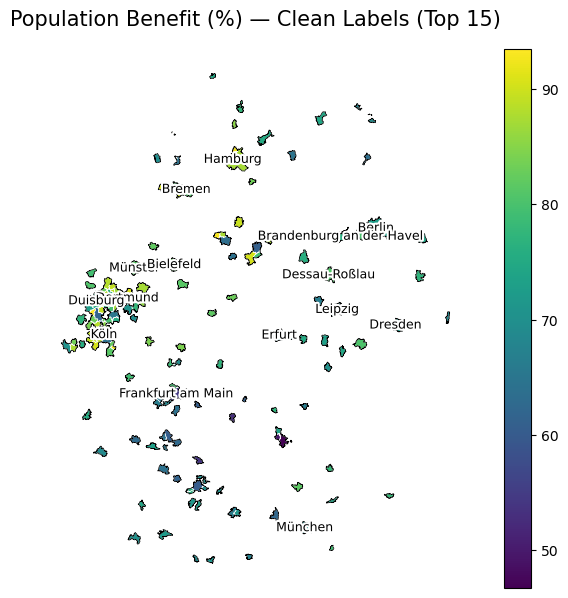

In [33]:
# --- Alternative clean labels cell (automatic): label only the TOP N areas to avoid clutter ---
# Useful when you don't want a manual list.
# Strategy:
#  - label only affected areas
#  - rank by polygon area (or by value_col), label top N
#  - add halo for readability

import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

name_col = "GEN"
N_LABELS = 15  # change to 10–25 depending on how clean you want it

affected = gdf[gdf[value_col].fillna(0) > 0].copy()

# Choose ONE ranking method:
# (A) Label biggest polygons (often more readable)
affected["_area_m2"] = affected.geometry.area
label_gdf = affected.nlargest(N_LABELS, "_area_m2").copy()

# (B) OR label highest values instead (uncomment to use)
# label_gdf = affected.nlargest(N_LABELS, value_col).copy()

# Borders
#city_borders = gdf.boundary
#country_outline = gdf.dissolve().boundary

# Plot
fig, ax = plt.subplots(figsize=(9, 7))

gdf.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey"}
)

city_borders.plot(ax=ax, linewidth=0.4, color="white", alpha=0.9)
country_outline.plot(ax=ax, linewidth=0.5, color="black")

# Labels with halo
pts = label_gdf.geometry.representative_point()
for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
    txt = ax.text(
        x, y, name,
        fontsize=9, fontweight="regular",
        ha="center", va="center",
        color="black",
        zorder=10
    )
    txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

ax.set_title(f"Population Benefit (%) — Clean Labels (Top {N_LABELS})", fontsize=15)
ax.set_axis_off()
plt.show()


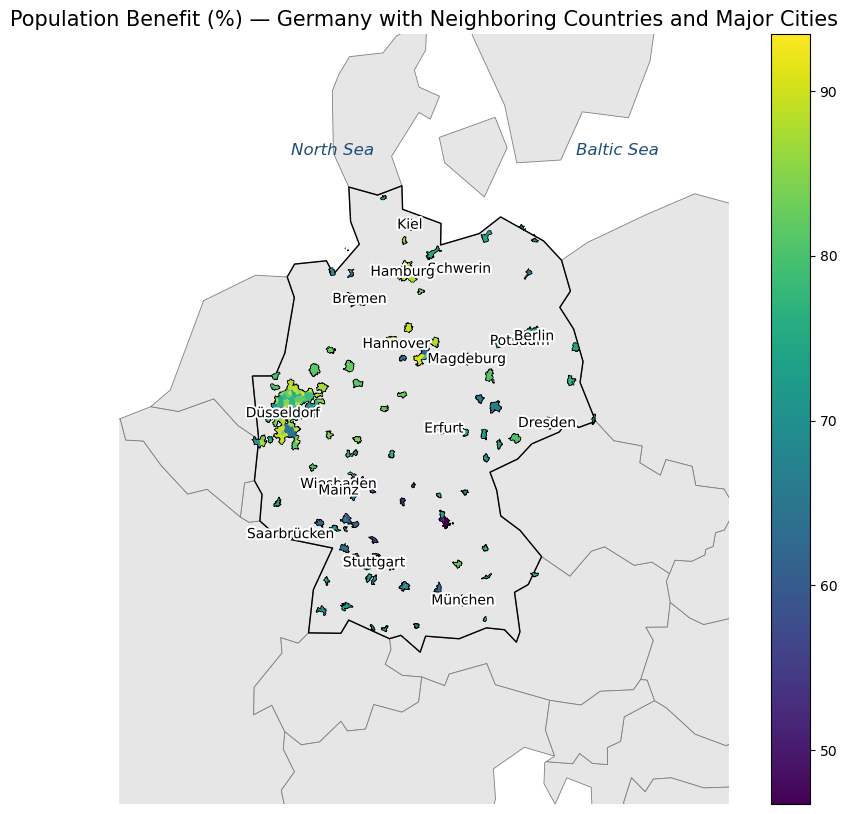

In [35]:
# --- Map with world context + clean minimal city labels ---

import matplotlib.patheffects as pe

# Select major cities to label (edit if needed)
major_cities = {
    "Hamburg", "Berlin", "München", "Munich", "Stuttgart",
    "Dresden", "Bremen", "Hannover", "Kiel",
    "Schwerin", "Potsdam", "Magdeburg",
    "Erfurt", "Wiesbaden", "Mainz",
    "Saarbrücken", "Saarbrucken", "Düsseldorf", "Duesseldorf"
}

name_col = "GEN"

# Filter to affected areas AND selected cities
affected = gdf_wgs[gdf_wgs[value_col].fillna(0) > 0]
label_gdf = affected[affected[name_col].astype(str).isin(major_cities)].copy()

fig, ax = plt.subplots(figsize=(11, 10))

# Sea background
ax.set_facecolor("#a7d8f0")

# Neighboring countries
nearby.plot(
    ax=ax,
    color="#e6e6e6",
    edgecolor="#7f7f7f",
    linewidth=0.6,
    zorder=1
)

# Germany outline from world dataset
germany.boundary.plot(ax=ax, color="black", linewidth=1.0, zorder=2)

# Thematic layer
gdf_wgs.plot(
    column=value_col,
    ax=ax,
    cmap="viridis",
    legend=True,
    edgecolor="none",
    missing_kwds={"color": "lightgrey"},
    zorder=3
)

# City/district borders
city_borders.plot(ax=ax, linewidth=0.35, color="white", alpha=0.9, zorder=4)

# Outer dataset border
country_outline_from_gdf.plot(ax=ax, linewidth=0.5, color="black", zorder=5)

# --- Add Clean City Labels ---
if len(label_gdf) > 0:
    pts = label_gdf.geometry.representative_point()
    for x, y, name in zip(pts.x, pts.y, label_gdf[name_col].astype(str)):
        txt = ax.text(
            x, y, name,
            fontsize=10,
            fontweight="regular",
            ha="center",
            va="center",
            color="black",
            zorder=10
        )
        # White halo for readability
        txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

# Sea labels
ax.text(7.0, 55.5, "North Sea", fontsize=12, fontstyle="italic", color="#1f4e79")
ax.text(14.5, 55.5, "Baltic Sea", fontsize=12, fontstyle="italic", color="#1f4e79")

# Final layout
ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_axis_off()
ax.set_title("Population Benefit (%) — Germany with Neighboring Countries and Major Cities", fontsize=15)

plt.show()
